# Model Training, Evaluation, GridSearch & SHAP
**Walmart Store Sales Forecasting**

---
### Outline
1. Imports & Load data_processed
2. Baseline Models Comparison
3. GridSearchCV on Best Model
4. Final Model Training
5. Evaluation Plots (Predicted vs Actual, Residuals)
6. SHAP Explainability
7. Save Final Model

## 1. Imports & Load data_processed

In [5]:
import numpy as np
import pandas as pd
import warnings
import joblib
import copy
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', font_scale=1.1)

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap

print('Libraries loaded!')

Libraries loaded!


In [6]:
X_train = pd.read_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/X_train.parquet')
X_val  = pd.read_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/X_val.parquet')
X_test = pd.read_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/X_test.parquet')
y_train = pd.read_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/y_train.parquet').squeeze()
y_val = pd.read_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/y_val.parquet').squeeze()
holiday_val  = pd.read_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/holiday_val.parquet').squeeze()
train_full  = pd.read_parquet(r'C:\Users\User\Desktop\project\Data sets\data_processed/train_full.parquet')
FEATURE_COLS = joblib.load(r'C:\Users\User\Desktop\project\models/feature_cols.pkl')
TARGET  = 'Weekly_Sales'

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')

X_train : (337256, 34)
X_val   : (84314, 34)
X_test  : (115064, 34)


## 2. Baseline Models Comparison

In [7]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, name):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    mae   = mean_absolute_error(y_v, preds)
    rmse  = np.sqrt(mean_squared_error(y_v, preds))
    r2    = r2_score(y_v, preds)
    print(f'{name:20s} |  MAE: {mae:10,.2f} | RMSE: {rmse:10,.2f} | R2: {r2:.4f}')
    return {'model': model, 'name': name, 'mae': mae, 'rmse': rmse, 'r2': r2, 'preds': preds}

In [14]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge'           : Ridge(alpha=1, random_state=42),
    'RandomForest'    : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'         : xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
}

print(f'{"Model":<20}  | {"MAE":>12} | {"RMSE":>12} | {"R2":>8}')

results = {}
for name, model in models.items():
    results[name] = evaluate_model(model, X_train, y_train, X_val, y_val, name)

Model                 |          MAE |         RMSE |       R2
LinearRegression     |  MAE:   1,329.65 | RMSE:   3,191.32 | R2: 0.9719
Ridge                |  MAE:   1,329.59 | RMSE:   3,188.78 | R2: 0.9719
RandomForest         |  MAE:   1,133.39 | RMSE:   2,675.23 | R2: 0.9802
XGBoost              |  MAE:   1,107.67 | RMSE:   2,773.98 | R2: 0.9788


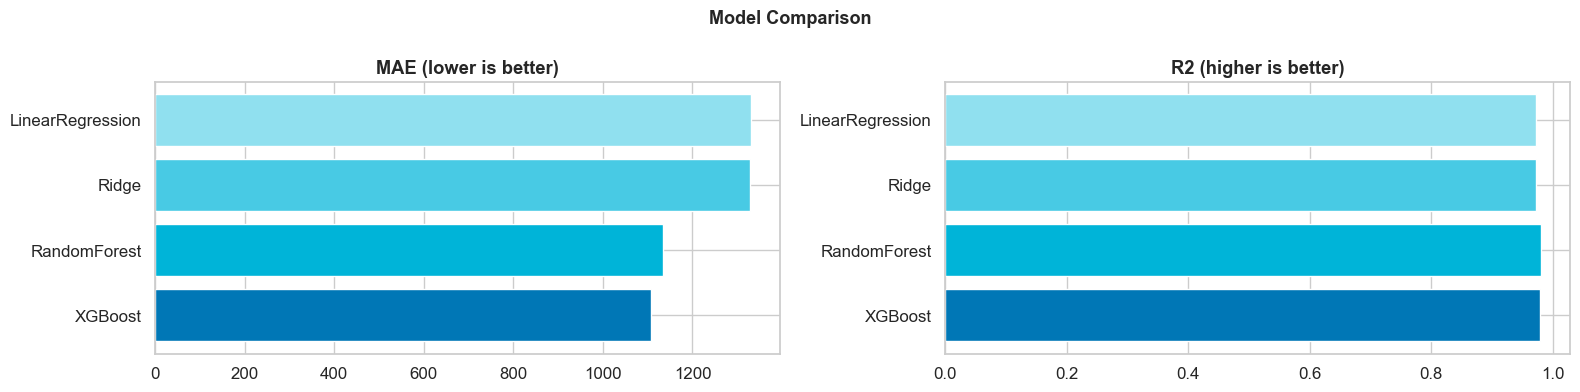

Best Model is: XGBoost


In [16]:
results_df = pd.DataFrame([
    {'Model': n, 'MAE': r['mae'], 'R2': r['r2']}
    for n, r in results.items()]).sort_values('MAE')

colors = ['#0077B6', '#00B4D8', '#48CAE4', '#90E0EF']
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].barh(results_df['Model'], results_df['MAE'],  color=colors)
axes[0].set_title('MAE (lower is better)',  fontweight='bold')

axes[1].barh(results_df['Model'], results_df['R2'],   color=colors)
axes[1].set_title('R2 (higher is better)', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\project\imgs/fig_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

best_model = results_df.loc[results_df['MAE'].idxmin(), 'Model']
print(f"Best Model is: {best_model}")

## 3. GridSearchCV on Best Model

In [21]:
param_grids = {'n_estimators': [100, 200, 300], 'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [3, 5, 7, 9]}

gs = GridSearchCV(estimator  = xgb.XGBRegressor(random_state=42), param_grid = param_grids, cv = 3,
    scoring = 'neg_mean_absolute_error', n_jobs = -1, verbose = 1)
gs.fit(X_train, y_train)

print(f'Best params : {gs.best_params_}')
# copy.deepcopy(results[best_model]['model'])

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params : {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 300}


In [22]:
tuned_model = gs.best_estimator_
tuned_preds = tuned_model.predict(X_val)

print('Tuned model on validation set:')
print(f'  MAE  : {mean_absolute_error(y_val, tuned_preds):,.2f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_val, tuned_preds)):,.2f}')
print(f'  R2   : {r2_score(y_val, tuned_preds):.4f}')

Tuned model on validation set:
  MAE  : 1,083.25
  RMSE : 2,727.33
  R2   : 0.9795


## 4. Final Model Training

In [23]:
X_all = pd.concat([X_train, X_val], ignore_index=True)
y_all = pd.concat([y_train, y_val], ignore_index=True)

final_model = copy.deepcopy(tuned_model)
final_model.fit(X_all, y_all)

test_preds = final_model.predict(X_test)

print(f'Trained on {len(X_all):,} samples')
print(f'Test preds range: {test_preds.min():,.2f}  to  {test_preds.max():,.2f}')

Trained on 421,570 samples
Test preds range: -411.11  to  541,746.25


## 5. Evaluation Plots

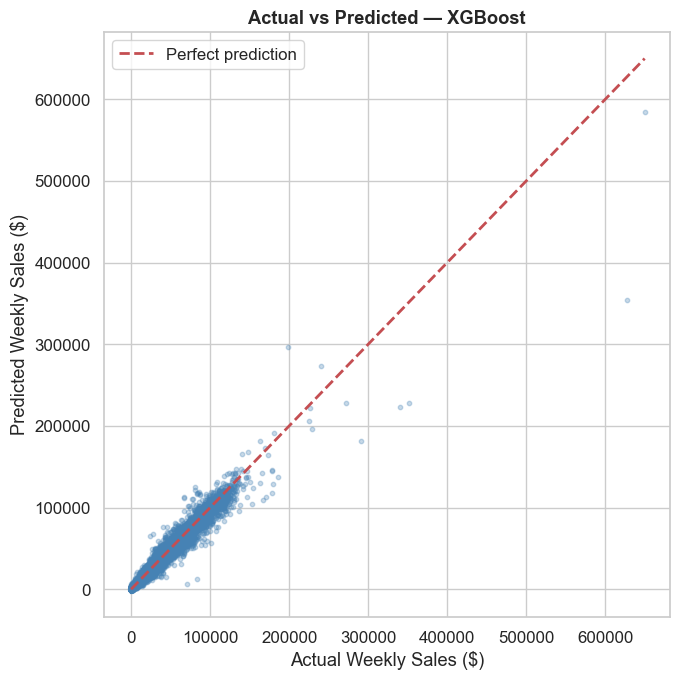

In [24]:
# Predicted vs Actual
plt.figure(figsize=(7, 7))
plt.scatter(y_val, tuned_preds, alpha=0.3, s=10, color='steelblue')
max_val = max(y_val.max(), tuned_preds.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Weekly Sales ($)')
plt.ylabel('Predicted Weekly Sales ($)')
plt.title(f'Actual vs Predicted — {best_model}', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\project\imgs/fig_actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()

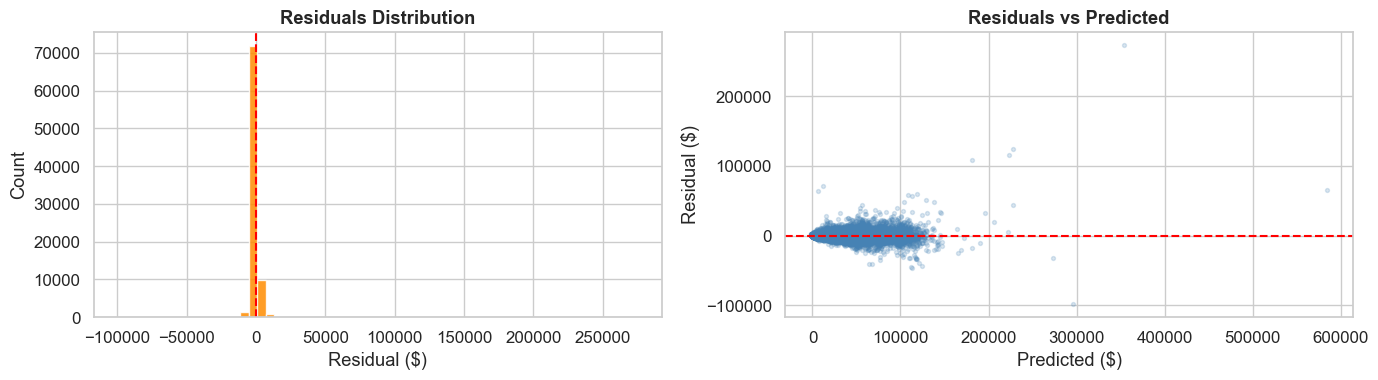

In [25]:
# Residuals
residuals = y_val.values - tuned_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residuals Distribution', fontweight='bold')
axes[0].set_xlabel('Residual ($)')
axes[0].set_ylabel('Count')

axes[1].scatter(tuned_preds, residuals, alpha=0.2, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')
axes[1].set_xlabel('Predicted ($)')
axes[1].set_ylabel('Residual ($)')

plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\project\imgs/fig_residuals.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. SHAP Explainability

In [26]:
X_shap = X_val.sample(min(1000, len(X_val)), random_state=42)

if best_model in ('RandomForest', 'XGBoost'):
    explainer   = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_shap)
elif best_model in ('LinearRegression', 'Ridge'):
    explainer   = shap.LinearExplainer(final_model, X_train)
    shap_values = explainer.shap_values(X_shap)
else:  # SVR
    explainer   = shap.KernelExplainer(final_model.predict, shap.sample(X_train, 100))
    shap_values = explainer.shap_values(X_shap)

print('SHAP values computed!')

SHAP values computed!


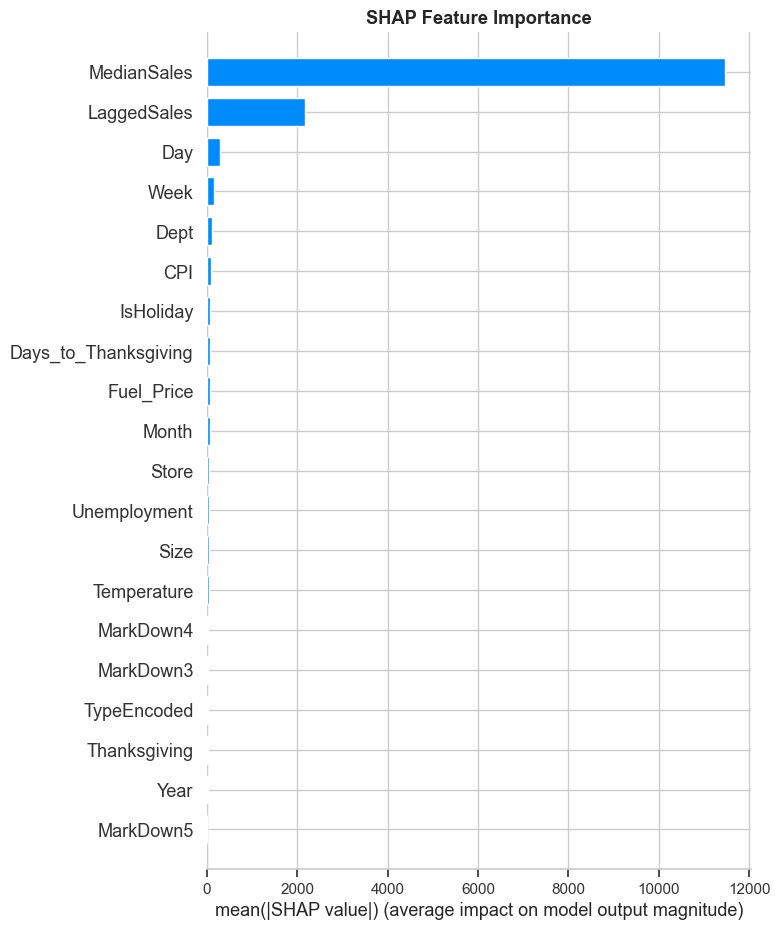

In [27]:
# Summary bar
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False)
plt.title('SHAP Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\project\imgs/fig_shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

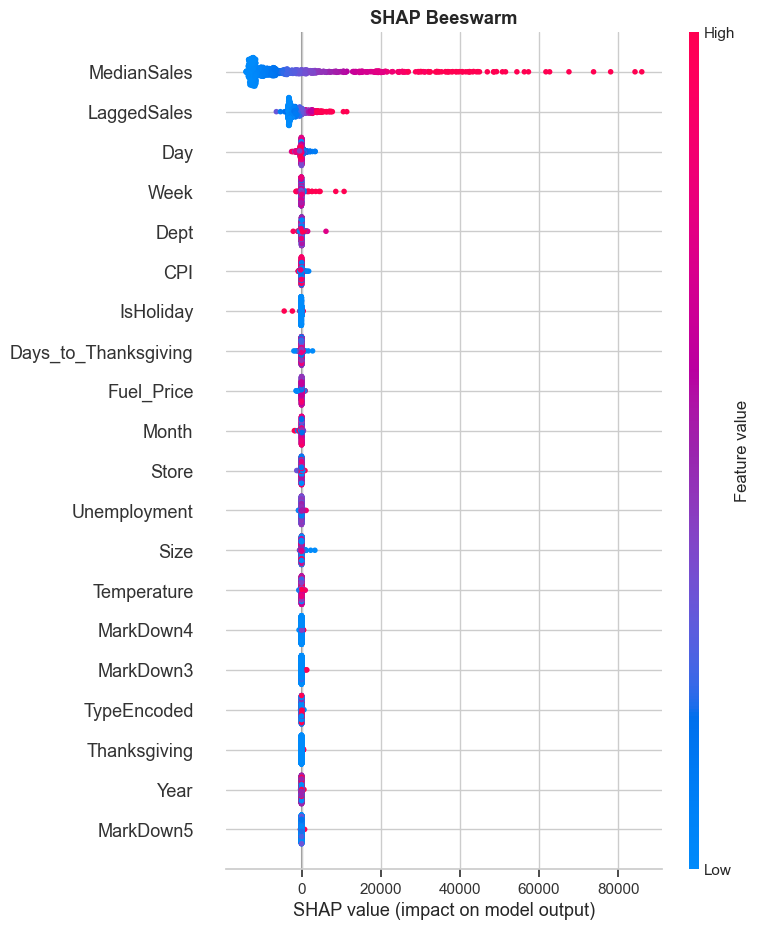

In [28]:
# Beeswarm
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Beeswarm', fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\project\imgs/fig_shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Save Final Model

In [29]:
print('FINAL SUMMARY')

print(f'Mode : {best_model}')
print(f'Best params : {gs.best_params_}')
print(f'MAE(val) : {mean_absolute_error(y_val, tuned_preds):,.2f}')
print(f'RMSE (val) : {np.sqrt(mean_squared_error(y_val, tuned_preds)):,.2f}')
print(f'R2(val) : {r2_score(y_val, tuned_preds):.4f}')

joblib.dump(final_model, r'C:\Users\User\Desktop\project\models/final_model.pkl')

FINAL SUMMARY
Mode : XGBoost
Best params : {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 300}
MAE(val) : 1,083.25
RMSE (val) : 2,727.33
R2(val) : 0.9795


['C:\\Users\\User\\Desktop\\project\\models/final_model.pkl']